In [8]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input,
    decode_predictions
)

# Load pretrained MobileNetV2 model
model = MobileNetV2(weights="imagenet")

print("Model loaded successfully!")

Model loaded successfully!


In [9]:
from google.colab import files

uploaded = files.upload()


Saving 2010-kodiak-bear-1.jpg to 2010-kodiak-bear-1.jpg


In [10]:
filename = list(uploaded.keys())[0]

print("Uploaded image:", filename)

Uploaded image: 2010-kodiak-bear-1.jpg


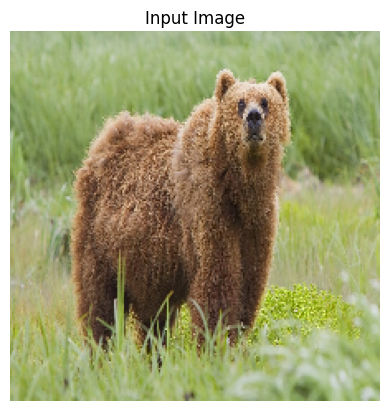

In [11]:
img = image.load_img(filename, target_size=(224, 224))

plt.imshow(img)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [12]:
# Convert image to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

# Preprocess image
img_array = preprocess_input(img_array)

# Predict
predictions = model.predict(img_array)

# Get top 5 predictions
results = decode_predictions(predictions, top=5)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [13]:
print("TOP 5 PREDICTIONS")
print("-" * 40)

for i, (_, label, probability) in enumerate(results):
    print(f"{i+1}. {label} : {probability * 100:.2f}%")

TOP 5 PREDICTIONS
----------------------------------------
1. brown_bear : 89.64%
2. American_black_bear : 0.37%
3. chow : 0.18%
4. wild_boar : 0.12%
5. sloth_bear : 0.09%
